# Neural Network Model: From Layers to Forward Propagation

---

# 1. Executive Summary

This lecture introduces the fundamental building blocks of neural networks, focusing on the architecture of neural network layers and the forward propagation algorithm for making predictions. The material builds from basic concepts—how individual neurons process information—to complex multi-layer networks capable of solving real-world problems like handwritten digit recognition.

The key learning objectives include understanding how a single layer of neurons transforms input vectors through logistic regression units, mastering the notation system (superscripts for layers, subscripts for neurons), and implementing forward propagation to compute predictions. By the end, learners will understand how to construct neural networks with multiple hidden layers and execute the sequential computations that propagate activations from input to output.

---

# 2. Key Concepts & Glossary

| **Term** | **Definition** |
|----------|----------------|
| **Neural Network Layer** | A collection of neurons that process input vectors and output activation vectors; the fundamental building block of neural networks |
| **Neuron/Unit** | A computational unit that implements a logistic regression function, taking multiple inputs and producing a single activation value |
| **Activation Value (a)** | The output of a neuron after applying the activation function; denoted with superscript for layer and subscript for neuron (e.g., $a_1^{[1]}$) |
| **Activation Function (g)** | The function that determines a neuron's output; in this lecture, the sigmoid function $g(z) = \frac{1}{1+e^{-z}}$ |
| **Weights (w)** | Parameters that determine the importance of each input feature to a neuron; each neuron has its own weight vector |
| **Bias (b)** | An additional parameter that shifts the neuron's activation threshold |
| **Hidden Layer** | A layer between input and output that is not directly observed in the final prediction |
| **Output Layer** | The final layer that produces the network's prediction |
| **Forward Propagation** | The algorithm for computing neural network predictions by propagating activations from input through successive layers |
| **Input Layer (Layer 0)** | The layer containing raw input features, not counted in the total number of layers |
| **Superscript [l]** | Notation indicating the layer number (e.g., $w^{[1]}$ are weights for layer 1) |
| **Subscript j** | Notation indicating the neuron number within a layer (e.g., $a_2^{[3]}$ is the 2nd neuron's activation in layer 3) |

---

# 3. Important Data Points

## Key Formulas

| **Formula** | **Description** |
|-------------|-----------------|
| $z = w \cdot x + b$ | Linear combination of inputs with weights and bias |
| $a = g(z) = \frac{1}{1+e^{-z}}$ | Sigmoid activation function |
| $a_j^{[l]} = g(w_j^{[l]} \cdot a^{[l-1]} + b_j^{[l]})$ | General formula for activation of neuron j in layer l |
| $\hat{y} = \begin{cases} 1 & \text{if } a > 0.5 \\ 0 & \text{otherwise} \end{cases}$ | Binary prediction thresholding |

## Example Network Architecture (Handwritten Digit Recognition)

| **Layer** | **Type** | **Number of Neurons** | **Input** | **Output** |
|-----------|----------|----------------------|-----------|------------|
| Layer 0 | Input | 64 | 8×8 image pixels | Raw features |
| Layer 1 | Hidden | 25 | $a^{[0]}$ (x) | $a^{[1]}$ (25D) |
| Layer 2 | Hidden | 15 | $a^{[1]}$ | $a^{[2]}$ (15D) |
| Layer 3 | Output | 1 | $a^{[2]}$ | $a^{[3]}$ (scalar) |

## Key Researchers
- **Andrew Ng** - Presenter and primary instructor

---

# 4. Core Concepts

## 4.1 The Neural Network Layer: A Collection of Logistic Regression Units

A neural network layer is fundamentally a group of neurons operating in parallel on the same input. Each neuron in a layer functions as an independent logistic regression unit, with its own set of parameters (weights and bias). The key insight is that these neurons can learn different features from the same input data.

Consider a hidden layer with three neurons. Each neuron receives the same input vector $x$ but applies different weights:
- Neuron 1: $a_1 = g(w_1 \cdot x + b_1)$
- Neuron 2: $a_2 = g(w_2 \cdot x + b_2)$  
- Neuron 3: $a_3 = g(w_3 \cdot x + b_3)$

The layer's output is the vector of these individual activations: $a = [a_1, a_2, a_3]$. This vector becomes the input to the next layer, creating a hierarchical feature learning system.

**Insight:** The parallel processing in a layer allows the network to extract multiple, potentially orthogonal features from the same input. For example, in demand prediction, one neuron might learn about affordability while another learns about consumer awareness.

## 4.2 Notation System: Keeping Layers Organized

Proper notation is crucial for understanding multi-layer networks. The lecture introduces a systematic notation:

- **Square brackets [l]** indicate the layer number
- **Subscript j** indicates the neuron number within that layer
- **Arrow notation $\vec{a}$** denotes vectors (though often omitted in equations)

For layer 1:
- $a^{[1]}$ - Vector output of layer 1
- $w_1^{[1]}, b_1^{[1]}$ - Parameters for neuron 1 in layer 1
- $a_1^{[1]} = g(w_1^{[1]} \cdot x + b_1^{[1]})$ - Activation of neuron 1 in layer 1

For layer 2:
- $a^{[2]}$ - Vector output of layer 2
- $w_1^{[2]}, b_1^{[2]}$ - Parameters for the single neuron in layer 2
- $a_1^{[2]} = g(w_1^{[2]} \cdot a^{[1]} + b_1^{[2]})$ - Final prediction

**Note:** The input layer is often denoted as layer 0 with $a^{[0]} = x$, making the pattern consistent: each layer's input is the previous layer's output.

## 4.3 Forward Propagation: The Inference Algorithm

Forward propagation is the algorithm for computing neural network predictions. It's called "forward" because computations flow from left to right through the network:

1. **Start with input:** $a^{[0]} = x$
2. **Compute layer 1:** $a^{[1]} = g(W^{[1]} \cdot a^{[0]} + b^{[1]})$
3. **Compute layer 2:** $a^{[2]} = g(W^{[2]} \cdot a^{[1]} + b^{[2]})$
4. **Continue through all layers** until reaching the output layer
5. **Optional thresholding:** Convert probability to binary prediction

For a network with L layers, the general step is:
$$a^{[l]} = g(W^{[l]} \cdot a^{[l-1]} + b^{[l]})$$

The final output $a^{[L]}$ (or $a^{[L]}_1$ if the output layer has one neuron) is the network's prediction.

**Key Insight:** Forward propagation is deterministic given the input and parameters. The network's "intelligence" comes from the parameter values learned during training—the forward propagation algorithm itself is straightforward matrix-vector operations followed by activation functions.

---

# 5. Visualizations

## 5.1 Single Neuron Structure


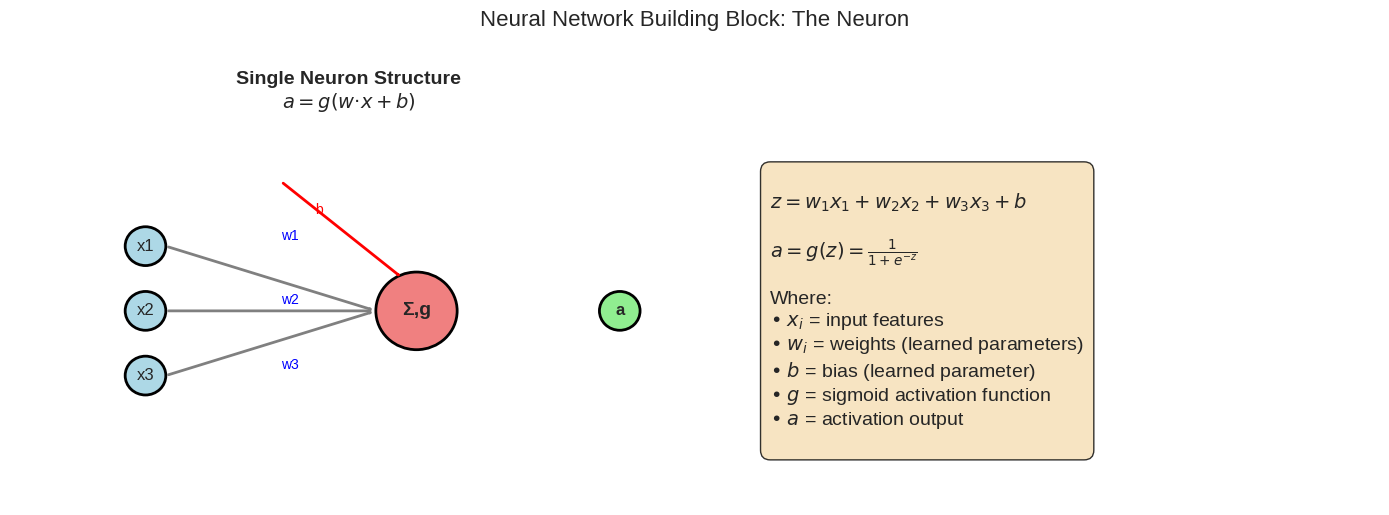

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle, FancyArrowPatch
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Left: Single neuron diagram
ax[0].set_xlim(0, 10)
ax[0].set_ylim(0, 6)
ax[0].axis('off')

# Input nodes
inputs = [(2, 4), (2, 3), (2, 2)]
for i, (x, y) in enumerate(inputs):
    circle = Circle((x, y), 0.3, color='lightblue', ec='black', linewidth=2)
    ax[0].add_patch(circle)
    ax[0].text(x, y, f'x{i+1}', ha='center', va='center', fontsize=12)

# Neuron
neuron = Circle((6, 3), 0.6, color='lightcoral', ec='black', linewidth=2)
ax[0].add_patch(neuron)
ax[0].text(6, 3, 'Σ,g', ha='center', va='center', fontsize=14, fontweight='bold')

# Output
output = Circle((9, 3), 0.3, color='lightgreen', ec='black', linewidth=2)
ax[0].add_patch(output)
ax[0].text(9, 3, 'a', ha='center', va='center', fontsize=12, fontweight='bold')

# Connections with weight labels
for i, (x, y) in enumerate(inputs):
    arrow = FancyArrowPatch((x+0.3, y), (5.4, 3),
                            arrowstyle='->', color='gray', linewidth=2)
    ax[0].add_patch(arrow)
    ax[0].text((x+6)/2, y+0.1, f'w{i+1}', fontsize=10, color='blue')

# Bias arrow
bias_arrow = FancyArrowPatch((4, 5), (5.8, 3.5),
                            arrowstyle='->', color='red', linewidth=2)
ax[0].add_patch(bias_arrow)
ax[0].text(4.5, 4.5, 'b', fontsize=10, color='red')

ax[0].set_title('Single Neuron Structure\n$a = g(w·x + b)$', fontsize=14, fontweight='bold')

# Right: Mathematical operation
ax[1].axis('off')
formula_text = """
$z = w_1x_1 + w_2x_2 + w_3x_3 + b$

$a = g(z) = \\frac{1}{1 + e^{-z}}$

Where:
• $x_i$ = input features
• $w_i$ = weights (learned parameters)
• $b$ = bias (learned parameter)
• $g$ = sigmoid activation function
• $a$ = activation output
"""
ax[1].text(0.1, 0.5, formula_text, fontsize=14, verticalalignment='center',
           bbox=dict(boxstyle="round,pad=0.5", facecolor="wheat", alpha=0.8))

plt.suptitle('Neural Network Building Block: The Neuron', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 5.2 Neural Network Layer Architecture

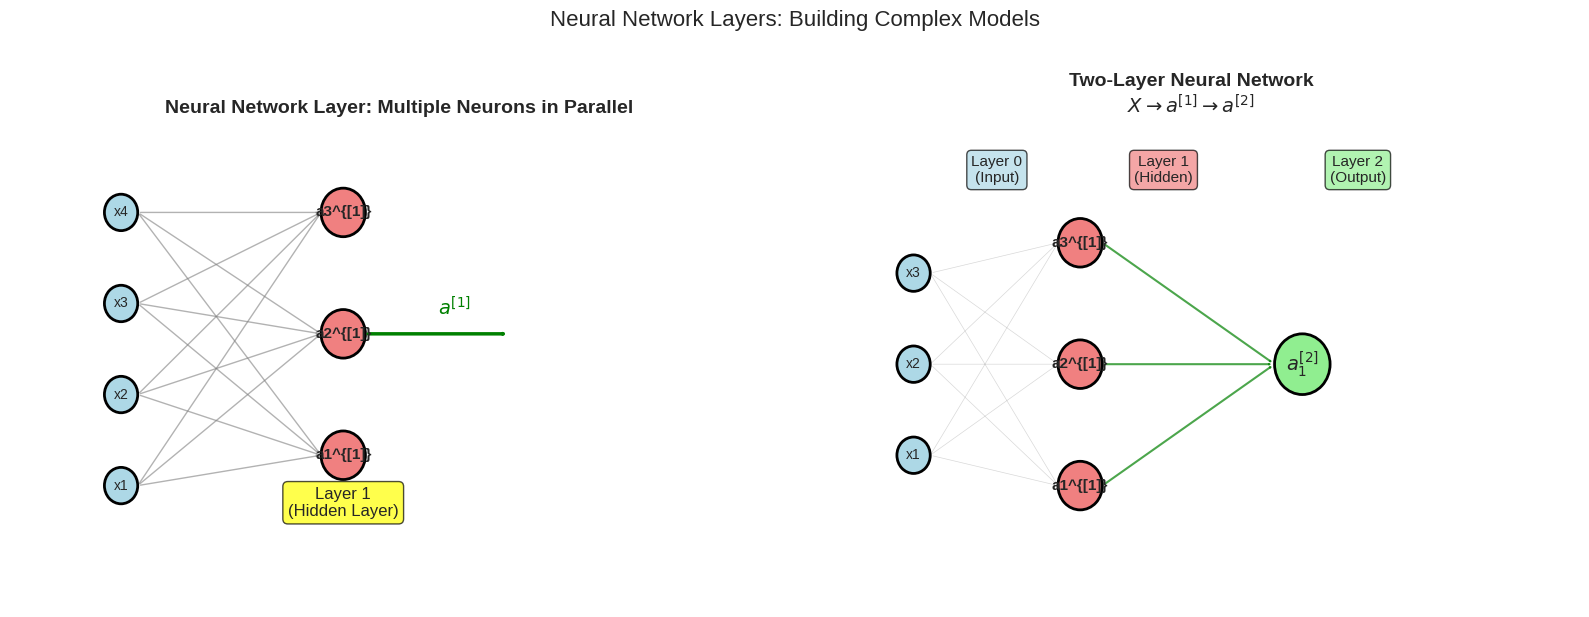

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle, FancyArrowPatch
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# ===== Left: Single Layer with Multiple Neurons =====
ax[0].set_xlim(0, 14)
ax[0].set_ylim(0, 8)
ax[0].axis('off')

# Input layer
input_nodes = [(2, 2), (2, 3.5), (2, 5), (2, 6.5)]
for i, (x, y) in enumerate(input_nodes):
    circle = Circle((x, y), 0.3, color='lightblue', ec='black', linewidth=2)
    ax[0].add_patch(circle)
    ax[0].text(x, y, f'x{i+1}', ha='center', va='center', fontsize=10)

# Layer 1 neurons (3 neurons)
layer1_neurons = [(6, 2.5), (6, 4.5), (6, 6.5)]
for i, (x, y) in enumerate(layer1_neurons):
    circle = Circle((x, y), 0.4, color='lightcoral', ec='black', linewidth=2)
    ax[0].add_patch(circle)
    ax[0].text(x, y, f'a{i+1}^{{[1]}}', ha='center', va='center', fontsize=11, fontweight='bold')

# Connect inputs to first neuron
for in_x, in_y in input_nodes:
    arrow = FancyArrowPatch((in_x+0.3, in_y), (5.6, 2.5),
                            arrowstyle='->', color='gray', alpha=0.6, linewidth=1)
    ax[0].add_patch(arrow)

# Connect inputs to second neuron
for in_x, in_y in input_nodes:
    arrow = FancyArrowPatch((in_x+0.3, in_y), (5.6, 4.5),
                            arrowstyle='->', color='gray', alpha=0.6, linewidth=1)
    ax[0].add_patch(arrow)

# Connect inputs to third neuron
for in_x, in_y in input_nodes:
    arrow = FancyArrowPatch((in_x+0.3, in_y), (5.6, 6.5),
                            arrowstyle='->', color='gray', alpha=0.6, linewidth=1)
    ax[0].add_patch(arrow)

# Output from layer 1 (vector)
output_vector = FancyArrowPatch((6.4, 4.5), (9, 4.5),
                               arrowstyle='->', color='green', linewidth=2.5)
ax[0].add_patch(output_vector)
ax[0].text(7.7, 4.8, '$a^{{[1]}}$', fontsize=14, fontweight='bold', color='green')

# Add layer label
ax[0].text(6, 1.5, 'Layer 1\n(Hidden Layer)', ha='center', fontsize=12,
           bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

ax[0].set_title('Neural Network Layer: Multiple Neurons in Parallel', fontsize=14, fontweight='bold')

# ===== Right: Two-Layer Network =====
ax[1].set_xlim(0, 14)
ax[1].set_ylim(0, 8)
ax[1].axis('off')

# Input layer (Layer 0)
input_nodes = [(2, 2.5), (2, 4), (2, 5.5)]
for i, (x, y) in enumerate(input_nodes):
    circle = Circle((x, y), 0.3, color='lightblue', ec='black', linewidth=2)
    ax[1].add_patch(circle)
    ax[1].text(x, y, f'x{i+1}', ha='center', va='center', fontsize=10)

# Layer 1 (3 neurons)
layer1_neurons = [(5, 2), (5, 4), (5, 6)]
for i, (x, y) in enumerate(layer1_neurons):
    circle = Circle((x, y), 0.4, color='lightcoral', ec='black', linewidth=2)
    ax[1].add_patch(circle)
    ax[1].text(x, y, f'a{i+1}^{{[1]}}', ha='center', va='center', fontsize=11, fontweight='bold')

# Connect inputs to layer 1 (simplified - just a few connections for clarity)
for in_x, in_y in input_nodes:
    for out_x, out_y in layer1_neurons:
        arrow = FancyArrowPatch((in_x+0.3, in_y), (out_x-0.4, out_y),
                                arrowstyle='->', color='gray', alpha=0.3, linewidth=0.5)
        ax[1].add_patch(arrow)

# Layer 2 (output layer - 1 neuron)
output_neuron = Circle((9, 4), 0.5, color='lightgreen', ec='black', linewidth=2)
ax[1].add_patch(output_neuron)
ax[1].text(9, 4, '$a_1^{{[2]}}$', ha='center', va='center', fontsize=14, fontweight='bold')

# Connect layer 1 to output
for out_x, out_y in layer1_neurons:
    arrow = FancyArrowPatch((out_x+0.4, out_y), (8.5, 4),
                            arrowstyle='->', color='green', alpha=0.7, linewidth=1.5)
    ax[1].add_patch(arrow)

# Layer labels
ax[1].text(3.5, 7, 'Layer 0\n(Input)', ha='center', fontsize=11,
           bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))
ax[1].text(6.5, 7, 'Layer 1\n(Hidden)', ha='center', fontsize=11,
           bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.7))
ax[1].text(10, 7, 'Layer 2\n(Output)', ha='center', fontsize=11,
           bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))

ax[1].set_title('Two-Layer Neural Network\n$X \\rightarrow a^{{[1]}} \\rightarrow a^{{[2]}}$',
                fontsize=14, fontweight='bold')

plt.suptitle('Neural Network Layers: Building Complex Models', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 5.3 Sigmoid Activation Function Visualization


/tmp/ipykernel_266/1714228695.py:67: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_266/1714228695.py:67: UserWarning: Glyph 7611 (\N{MODIFIER LETTER SMALL Z}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINU

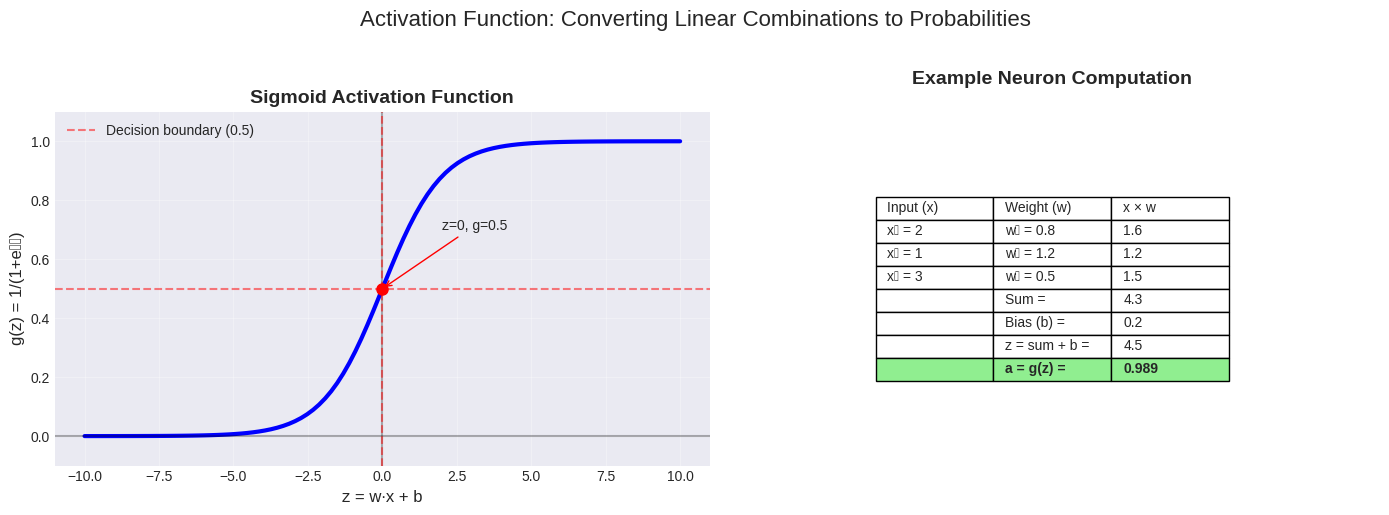

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ===== Left: Sigmoid Function =====
z = np.linspace(-10, 10, 100)
g = 1 / (1 + np.exp(-z))

axes[0].plot(z, g, 'b-', linewidth=3)
axes[0].axhline(y=0, color='k', linestyle='-', alpha=0.3)
axes[0].axvline(x=0, color='k', linestyle='-', alpha=0.3)
axes[0].axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Decision boundary (0.5)')
axes[0].axvline(x=0, color='r', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('z = w·x + b', fontsize=12)
axes[0].set_ylabel('g(z) = 1/(1+e⁻ᶻ)', fontsize=12)
axes[0].set_title('Sigmoid Activation Function', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].set_ylim(-0.1, 1.1)

# Annotate key points
axes[0].plot(0, 0.5, 'ro', markersize=8)
axes[0].annotate('z=0, g=0.5', xy=(0, 0.5), xytext=(2, 0.7),
                arrowprops=dict(arrowstyle='->', color='red'))

# ===== Right: Neuron Activation Visualization =====
axes[1].axis('off')

# Create a visual representation of how input affects activation
x_weights = [0.8, 1.2, 0.5]  # Example weights
bias = 0.2
inputs = np.array([2, 1, 3])  # Example inputs

# Calculate z and activation
z_example = np.dot(x_weights, inputs) + bias
a_example = 1 / (1 + np.exp(-z_example))

# Create table-like visualization
table_data = [
    ['Input (x)', 'Weight (w)', 'x × w'],
    [f'x₁ = {inputs[0]}', f'w₁ = {x_weights[0]}', f'{inputs[0]*x_weights[0]}'],
    [f'x₂ = {inputs[1]}', f'w₂ = {x_weights[1]}', f'{inputs[1]*x_weights[1]}'],
    [f'x₃ = {inputs[2]}', f'w₃ = {x_weights[2]}', f'{inputs[2]*x_weights[2]}'],
    ['', 'Sum =', f'{np.dot(x_weights, inputs):.1f}'],
    ['', 'Bias (b) =', f'{bias}'],
    ['', 'z = sum + b =', f'{z_example:.1f}'],
    ['', 'a = g(z) =', f'{a_example:.3f}']
]

# Create the table
table = axes[1].table(cellText=table_data, loc='center', cellLoc='left', colWidths=[0.15, 0.15, 0.15])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Color the last row (result)
for i in range(3):
    table[(7, i)].set_facecolor('lightgreen')
    table[(7, i)].set_text_props(weight='bold')

axes[1].set_title('Example Neuron Computation', fontsize=14, fontweight='bold', pad=20)

plt.suptitle('Activation Function: Converting Linear Combinations to Probabilities',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


## 5.4 Forward Propagation Flow



```python
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(1, 1, figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 6)
ax.axis('off')

# Create boxes for each computational step
# Input box
input_box = FancyBboxPatch((1, 2.5), 1.5, 1, boxstyle="round,pad=0.1",
                           facecolor='lightblue', edgecolor='black', linewidth=2)
ax.add_patch(input_box)
ax.text(1.75, 3, 'Input\nx = a⁰', ha='center', va='center', fontsize=11, fontweight='bold')

# Layer 1 box
layer1_box = FancyBboxPatch((4, 1.5), 2, 3, boxstyle="round,pad=0.1",
                            facecolor='lightcoral', edgecolor='black', linewidth=2)
ax.add_patch(layer1_box)
ax.text(5, 3.5, 'Layer 1\n(Hidden)', ha='center', va='center', fontsize=11, fontweight='bold')
ax.text(5, 2.5, 'a¹ = g(W¹·a⁰ + b¹)', ha='center', va='center', fontsize=10, style='italic')
ax.text(5, 1.8, '25 neurons', ha='center', va='center', fontsize=9)

# Layer 2 box
layer2_box = FancyBboxPatch((7, 2), 2, 2, boxstyle="round,pad=0.1",
                            facecolor='lightcoral', edgecolor='black', linewidth=2)
ax.add_patch(layer2_box)
ax.text(8, 3.2, 'Layer 2\n(Hidden)', ha='center', va='center', fontsize=11, fontweight='bold')
ax.text(8, 2.5, 'a² = g(W²·a¹ + b²)', ha='center', va='center', fontsize=10, style='italic')
ax.text(8, 2, '15 neurons', ha='center', va='center', fontsize=9)

# Output layer box
output_box = FancyBboxPatch((10.5, 2.5), 1.5, 1, boxstyle="round,pad=0.1",
                            facecolor='lightgreen', edgecolor='black', linewidth=2)
ax.add_patch(output_box)
ax.text(11.25, 3, 'Output\na³ = ŷ', ha='center', va='center', fontsize=11, fontweight='bold')

# Optional threshold box
threshold_box = FancyBboxPatch((10.5, 0.5), 1.5, 1, boxstyle="round,pad=0.1",
                               facecolor='wheat', edgecolor='black', linewidth=2, alpha=0.7)
ax.add_patch(threshold_box)
ax.text(11.25, 1, 'Threshold\nat 0.5', ha='center', va='center', fontsize=10)

# Arrows between boxes
arrow1 = FancyArrowPatch((2.5, 3), (4, 3), arrowstyle='->', color='black', linewidth=2)
ax.add_patch(arrow1)
ax.text(3.25, 3.2, 'a⁰', fontsize=12, fontweight='bold')

arrow2 = FancyArrowPatch((6, 3), (7, 3), arrowstyle='->', color='black', linewidth=2)
ax.add_patch(arrow2)
ax.text(6.5, 3.2, 'a¹', fontsize=12, fontweight='bold')

arrow3 = FancyArrowPatch((9, 3), (10.5, 3), arrowstyle='->', color='black', linewidth=2)
ax.add_patch(arrow3)
ax.text(9.75, 3.2, 'a²', fontsize=12, fontweight='bold')

arrow4 = FancyArrowPatch((11.25, 2.5), (11.25, 1.5), arrowstyle='->', color='black', linewidth=1.5, linestyle='--')
ax.add_patch(arrow4)
ax.text(11.8, 2, 'Optional', fontsize=9)

# Title
ax.set_title('Forward Propagation: Sequential Computation Through Layers',
             fontsize=16, fontweight='bold', pad=20)

# Add explanation text
explanation = """
Forward Propagation Algorithm:
1. Start with input a⁰ = x
2. Compute a¹ = g(W¹·a⁰ + b¹)
3. Compute a² = g(W²·a¹ + b²)
4. Compute a³ = g(W³·a² + b³)
5. Optionally threshold a³ for binary prediction
"""
ax.text(1, 5, explanation, fontsize=12,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.9))

plt.tight_layout()
plt.show()
```

---

# 6. Code Examples

## 6.1 Implementing a Single Neuron

```python
import numpy as np
import matplotlib.pyplot as plt

class Neuron:
    """
    A single neuron implementing logistic regression
    """
    def __init__(self, n_inputs):
        """Initialize neuron with random weights and bias"""
        self.w = np.random.randn(n_inputs) * 0.01
        self.b = 0.0
    
    def sigmoid(self, z):
        """Sigmoid activation function"""
        return 1 / (1 + np.exp(-z))
    
    def forward(self, x):
        """
        Forward pass through the neuron
        x: input vector (n_inputs,)
        returns: activation a
        """
        z = np.dot(self.w, x) + self.b
        a = self.sigmoid(z)
        return a
    
    def __call__(self, x):
        return self.forward(x)

# Example usage
np.random.seed(42)
neuron = Neuron(n_inputs=3)

# Test with sample input
x_test = np.array([2.0, 1.5, 3.0])
activation = neuron(x_test)

print("=" * 50)
print("SINGLE NEURON DEMONSTRATION")
print("=" * 50)
print(f"Input features: {x_test}")
print(f"Weights: {neuron.w}")
print(f"Bias: {neuron.b:.4f}")
print(f"z = w·x + b = {np.dot(neuron.w, x_test):.4f} + {neuron.b:.4f} = {np.dot(neuron.w, x_test) + neuron.b:.4f}")
print(f"Activation a = sigmoid(z) = {activation:.4f}")
print("=" * 50)
```

## 6.2 Implementing a Neural Network Layer

```python
import numpy as np

class Layer:
    """
    A neural network layer with multiple neurons
    """
    def __init__(self, n_inputs, n_neurons):
        """
        Initialize layer
        n_inputs: number of input features
        n_neurons: number of neurons in this layer
        """
        # Initialize weights and biases
        self.W = np.random.randn(n_neurons, n_inputs) * 0.01
        self.b = np.zeros((n_neurons, 1))
        self.n_neurons = n_neurons
    
    def sigmoid(self, z):
        """Sigmoid activation function"""
        return 1 / (1 + np.exp(-z))
    
    def forward(self, a_prev):
        """
        Forward propagation through the layer
        a_prev: activations from previous layer (n_inputs, 1) or (n_inputs,)
        returns: activations of current layer (n_neurons, 1)
        """
        # Ensure input is column vector
        if a_prev.ndim == 1:
            a_prev = a_prev.reshape(-1, 1)
        
        # Linear transformation
        z = np.dot(self.W, a_prev) + self.b
        
        # Activation
        a = self.sigmoid(z)
        
        return a
    
    def __call__(self, a_prev):
        return self.forward(a_prev)

# Example: Create a hidden layer with 3 neurons, 4 inputs
np.random.seed(42)
hidden_layer = Layer(n_inputs=4, n_neurons=3)

# Sample input (4 features)
x = np.array([0.5, 1.2, -0.3, 0.8])

# Forward pass through layer
a1 = hidden_layer(x)

print("=" * 50)
print("NEURAL NETWORK LAYER DEMONSTRATION")
print("=" * 50)
print(f"Input shape: {x.shape}")
print(f"Weight matrix shape: {hidden_layer.W.shape}")
print(f"Bias shape: {hidden_layer.b.shape}")
print(f"\nInput vector: {x}")
print(f"\nLayer output (activations):")
for i in range(hidden_layer.n_neurons):
    print(f"  Neuron {i+1}: {a1[i, 0]:.4f}")
print("=" * 50)
```

## 6.3 Complete Forward Propagation for Handwritten Digit Recognition

```python
import numpy as np
import matplotlib.pyplot as plt

class NeuralNetwork:
    """
    A multi-layer neural network for binary classification
    """
    def __init__(self, layer_dims):
        """
        Initialize neural network
        layer_dims: list containing dimensions of each layer
                   [input_dim, hidden1_dim, hidden2_dim, output_dim]
        """
        self.layer_dims = layer_dims
        self.layers = []
        self.parameters = {}
        
        # Create layers
        for l in range(1, len(layer_dims)):
            layer = Layer(layer_dims[l-1], layer_dims[l])
            self.layers.append(layer)
            self.parameters[f'W{l}'] = layer.W
            self.parameters[f'b{l}'] = layer.b
    
    def forward_propagation(self, X):
        """
        Complete forward propagation through all layers
        X: input data (input_dim, m) where m is number of examples
        returns: final output and cache of all activations
        """
        caches = []
        A = X
        
        # Store input as A0
        caches.append(A.copy())
        
        # Forward through each layer
        for l, layer in enumerate(self.layers):
            A_prev = A
            A = layer(A_prev)
            caches.append(A.copy())
        
        return A, caches
    
    def predict(self, X, threshold=0.5):
        """
        Make predictions for input data
        X: input data (input_dim, m)
        threshold: probability threshold for binary classification
        returns: binary predictions (1, m)
        """
        A_final, _ = self.forward_propagation(X)
        predictions = (A_final > threshold).astype(int)
        return predictions
    
    def predict_proba(self, X):
        """Return probability predictions"""
        A_final, _ = self.forward_propagation(X)
        return A_final

# Example: Network for handwritten digit recognition (0 vs 1)
# Architecture: 64 inputs → 25 neurons → 15 neurons → 1 output
np.random.seed(42)
model = NeuralNetwork([64, 25, 15, 1])

# Simulate a single 8x8 image (flattened to 64 pixels)
# Create a simple pattern resembling a '1'
image = np.zeros((8, 8))
image[:, 4] = 255  # Vertical line in middle
X_test = image.flatten().reshape(-1, 1)  # Shape: (64, 1)

# Forward propagation
probability, activations = model.forward_propagation(X_test)
prediction = model.predict(X_test)

# Visualize the results
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Plot original image
axes[0, 0].imshow(image, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Input Image (8×8)\nLayer 0 (Input)', fontsize=12)
axes[0, 0].axis('off')

# Plot activation patterns for each layer
layer_names = ['Layer 1 (Hidden)\n25 neurons',
               'Layer 2 (Hidden)\n15 neurons',
               'Layer 3 (Output)\n1 neuron']

for i in range(1, 4):
    row = (i) // 3
    col = (i) % 3
    activations_i = activations[i].flatten()
    
    axes[row, col].bar(range(len(activations_i)), activations_i, color='steelblue')
    axes[row, col].set_title(f'{layer_names[i-1]}', fontsize=12)
    axes[row, col].set_xlabel('Neuron Index')
    axes[row, col].set_ylabel('Activation')
    axes[row, col].set_ylim(0, 1)
    axes[row, col].axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Threshold')
    if i == 3:
        axes[row, col].legend()

# Add overall title
plt.suptitle('Forward Propagation Through Neural Network\nHandwritten Digit Recognition',
             fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

print("=" * 60)
print("FORWARD PROPAGATION RESULTS")
print("=" * 60)
print(f"Input shape: {X_test.shape}")
print(f"Final probability (digit is 1): {probability[0, 0]:.4f}")
print(f"Binary prediction (threshold 0.5): {prediction[0, 0]}")
print(f"\nActivation statistics:")
for i, act in enumerate(activations):
    if i == 0:
        print(f"  Layer {i} (Input): shape {act.shape}")
    else:
        print(f"  Layer {i}: shape {act.shape}, mean={np.mean(act):.4f}, std={np.std(act):.4f}")
print("=" * 60)
```

## 6.4 Visualization of Neuron Activations Across Layers

```python
import numpy as np
import matplotlib.pyplot as plt

def generate_digit_images():
    """Generate simple patterns for digits 0 and 1"""
    images = []
    labels = []
    
    # Generate multiple variations of '0' (oval shape)
    for i in range(5):
        img = np.zeros((8, 8))
        # Draw an oval
        for r in range(8):
            for c in range(8):
                if ((r-3.5)**2/9 + (c-3.5)**2/16) <= 1:
                    img[r, c] = 200 + np.random.randint(0, 55)
        images.append(img)
        labels.append(0)
    
    # Generate multiple variations of '1' (vertical line)
    for i in range(5):
        img = np.zeros((8, 8))
        # Draw a vertical line
        img[:, 4] = 200 + np.random.randint(0, 55)
        images.append(img)
        labels.append(1)
    
    return images, labels

# Create network and test with multiple images
model = NeuralNetwork([64, 25, 15, 1])
images, labels = generate_digit_images()

# Store activations for each layer
layer0_acts = []  # Input images
layer1_acts = []  # First hidden layer
layer2_acts = []  # Second hidden layer
layer3_acts = []  # Output layer

for img in images:
    X = img.flatten().reshape(-1, 1)
    _, activations = model.forward_propagation(X)
    layer0_acts.append(activations[0].flatten())
    layer1_acts.append(activations[1].flatten())
    layer2_acts.append(activations[2].flatten())
    layer3_acts.append(activations[3].flatten())

# Visualize activations for a few examples
fig, axes = plt.subplots(4, 4, figsize=(14, 12))

example_indices = [0, 5, 2, 7]  # Mix of 0s and 1s
example_labels = ['0', '1', '0', '1']

for col, idx in enumerate(example_indices):
    # Show input image
    axes[0, col].imshow(images[idx], cmap='gray')
    axes[0, col].set_title(f'Input: Digit {example_labels[col]}', fontsize=10)
    axes[0, col].axis('off')
    
    # Layer 1 activations
    axes[1, col].bar(range(25), layer1_acts[idx], color='steelblue', alpha=0.7)
    axes[1, col].set_ylim(0, 1)
    axes[1, col].set_ylabel('Layer 1', fontsize=9)
    if col == 0:
        axes[1, col].set_ylabel('Layer 1\nActivations', fontsize=9)
    
    # Layer 2 activations
    axes[2, col].bar(range(15), layer2_acts[idx], color='coral', alpha=0.7)
    axes[2, col].set_ylim(0, 1)
    if col == 0:
        axes[2, col].set_ylabel('Layer 2\nActivations', fontsize=9)
    
    # Layer 3 output
    axes[3, col].bar(['Output'], [layer3_acts[idx][0]], color='lightgreen', alpha=0.7)
    axes[3, col].set_ylim(0, 1)
    axes[3, col].axhline(y=0.5, color='r', linestyle='--', alpha=0.7)
    axes[3, col].set_ylabel('Output\nProbability', fontsize=9)

plt.suptitle('Neuron Activation Patterns for Different Input Digits', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
```



---

# 7. Key Takeaways

1. **Neural networks are built from layers of logistic regression units** - Each neuron in a layer performs the same computation: a weighted sum of inputs plus bias, passed through an activation function (sigmoid).

2. **Layers transform vectors into vectors** - A layer takes an input vector and produces an output vector, with each element representing a neuron's activation. This vector-to-vector transformation enables hierarchical feature learning.

3. **Proper notation is essential** - Superscripts [l] denote layers, subscripts j denote neurons within a layer. Understanding $a_j^{[l]} = g(w_j^{[l]} \cdot a^{[l-1]} + b_j^{[l]})$ is key to working with neural networks.

4. **Forward propagation is sequential computation** - Information flows from input through each layer: $a^{[0]} \rightarrow a^{[1]} \rightarrow a^{[2]} \rightarrow ... \rightarrow a^{[L]}$. Each step is deterministic given the parameters.

5. **Network architecture choices matter** - The number of layers and neurons per layer are design decisions. Common patterns include decreasing neuron counts as you approach the output.

6. **Activation functions introduce nonlinearity** - Without nonlinear activation functions like sigmoid, stacking layers would be equivalent to a single linear transformation.

7. **Output interpretation depends on the task** - For binary classification, the output layer's activation represents probability, which can be thresholded at 0.5 for discrete predictions.

8. **The input layer is Layer 0** - By convention, the input is $a^{[0]}$, making the formula $a^{[l]} = g(W^{[l]} \cdot a^{[l-1]} + b^{[l]})$ work consistently for all layers.

---

# 8. Quick Revision

## Key Formulas

| **Formula** | **Description** | **Terms** |
|-------------|-----------------|-----------|
| $z = w \cdot x + b$ | Linear combination | $w$: weights, $x$: inputs, $b$: bias |
| $a = g(z) = \frac{1}{1+e^{-z}}$ | Sigmoid activation | $g$: activation function |
| $a_j^{[l]} = g(w_j^{[l]} \cdot a^{[l-1]} + b_j^{[l]})$ | Neuron j in layer l | $l$: layer index, $j$: neuron index |
| $a^{[l]} = g(W^{[l]} \cdot a^{[l-1]} + b^{[l]})$ | Layer l forward pass | $W^{[l]}$: weight matrix for layer l |
| $\hat{y} = \begin{cases} 1 & a > 0.5 \\ 0 & \text{otherwise} \end{cases}$ | Binary prediction | $\hat{y}$: predicted class |

## Network Architecture Notation

| **Symbol** | **Meaning** | **Example** |
|------------|-------------|-------------|
| $a^{[0]}$ | Input layer (Layer 0) | $x_1, x_2, ..., x_n$ |
| $a^{[1]}$ | First hidden layer output | Vector of activations |
| $a_3^{[2]}$ | 3rd neuron's activation in layer 2 | Single number |
| $W^{[1]}$ | Weight matrix for layer 1 | Shape: (neurons_in_layer1 × input_dim) |
| $b^{[1]}$ | Bias vector for layer 1 | Shape: (neurons_in_layer1 × 1) |

## Forward Propagation Algorithm

```python
# Pseudocode for forward propagation
def forward_propagation(X, parameters):
    A = X  # a[0]
    cache = [A]
    
    for l in range(1, L+1):
        W = parameters[f'W{l}']
        b = parameters[f'b{l}']
        Z = np.dot(W, A) + b
        A = sigmoid(Z)  # a[l]
        cache.append(A)
    
    return A, cache  # Final prediction and all activations
```

## Common Activation Values Interpretation

| **Activation Range** | **Interpretation** |
|----------------------|-------------------|
| 0.0 - 0.1 | Strongly negative response |
| 0.1 - 0.4 | Weakly negative response |
| 0.4 - 0.6 | Uncertain / borderline |
| 0.6 - 0.9 | Weakly positive response |
| 0.9 - 1.0 | Strongly positive response |

## Layer Count Convention
- "4-layer neural network" = 3 hidden layers + 1 output layer
- Input layer (Layer 0) is NOT counted
- Each hidden layer + output layer counts as one layer